***Estrutucuración del proyecto***

*Instalar y desplegar librerias*

In [1]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn plotly jupyter prophet



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

# Utilidades
import warnings
warnings.filterwarnings('ignore')


*Leer archivos*

In [3]:
from pathlib import Path
import pandas as pd

carpeta = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Productos")
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
         "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
años = ["2024", "2025", "2026"]

productos = {}
for año in años:
    for mes in meses:
        archivo = f"{mes}-{año}.xlsx"
        ruta = carpeta / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=7)
            productos[f"{mes}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

carpeta_2 = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Facturas_lugar")
lugares = ["CP", "Principal"]

factura_lugar = {}
for año in años:
    for lugar in lugares:
        archivo = f"{lugar}-{año}.xlsx"
        ruta = carpeta_2 / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=6)
            factura_lugar[f"{lugar}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

print("Productos cargados:", list(productos.keys()))
print("Facturas lugar cargadas:", list(factura_lugar.keys()))


No encontrado: Enero-2024.xlsx
No encontrado: Febrero-2024.xlsx
No encontrado: Marzo-2024.xlsx
No encontrado: Abril-2024.xlsx
No encontrado: Mayo-2024.xlsx
No encontrado: Junio-2024.xlsx
No encontrado: Julio-2024.xlsx
No encontrado: Marzo-2026.xlsx
No encontrado: Abril-2026.xlsx
No encontrado: Mayo-2026.xlsx
No encontrado: Junio-2026.xlsx
No encontrado: Julio-2026.xlsx
No encontrado: Agosto-2026.xlsx
No encontrado: Septiembre-2026.xlsx
No encontrado: Octubre-2026.xlsx
No encontrado: Noviembre-2026.xlsx
No encontrado: Diciembre-2026.xlsx
No encontrado: CP-2024.xlsx
No encontrado: Principal-2024.xlsx
No encontrado: CP-2026.xlsx
No encontrado: Principal-2026.xlsx
Productos cargados: ['Agosto-2024', 'Septiembre-2024', 'Octubre-2024', 'Noviembre-2024', 'Diciembre-2024', 'Enero-2025', 'Febrero-2025', 'Marzo-2025', 'Abril-2025', 'Mayo-2025', 'Junio-2025', 'Julio-2025', 'Agosto-2025', 'Septiembre-2025', 'Octubre-2025', 'Noviembre-2025', 'Diciembre-2025', 'Enero-2026', 'Febrero-2026']
Facturas 

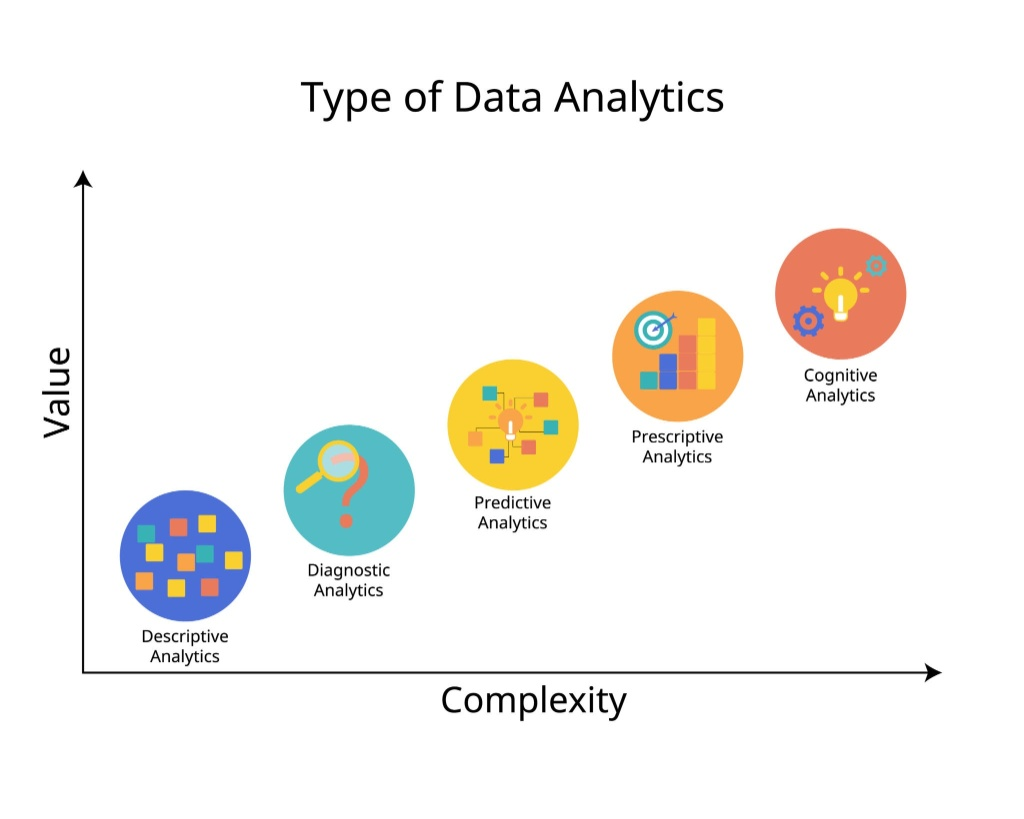

*Verificar fechas de los acrhivos*

In [4]:
col_fecha = "Fecha elaboración"
for mes, df in productos.items():
    df[col_fecha] = pd.to_datetime(df[col_fecha], dayfirst=True, errors="coerce")
    inicio = df[col_fecha].min()
    fin = df[col_fecha].max()
    print(f"{mes}: {inicio.date()} → {fin.date()}")



Agosto-2024: 2024-08-03 → 2024-08-30
Septiembre-2024: 2024-09-06 → 2024-09-24
Octubre-2024: 2024-10-04 → 2024-10-21
Noviembre-2024: 2024-11-25 → 2024-11-25
Diciembre-2024: 2024-12-04 → 2024-12-12
Enero-2025: 2025-01-08 → 2025-01-31
Febrero-2025: 2025-02-01 → 2025-02-28
Marzo-2025: 2025-03-02 → 2025-03-31
Abril-2025: 2025-04-01 → 2025-04-30
Mayo-2025: 2025-05-01 → 2025-05-31
Junio-2025: 2025-06-03 → 2025-06-30
Julio-2025: 2025-07-01 → 2025-07-31
Agosto-2025: 2025-08-04 → 2025-08-31
Septiembre-2025: 2025-09-01 → 2025-09-30
Octubre-2025: 2025-10-01 → 2025-10-31
Noviembre-2025: 2025-11-04 → 2025-11-30
Diciembre-2025: 2025-12-01 → 2025-12-31
Enero-2026: 2026-01-07 → 2026-01-31
Febrero-2026: 2026-02-02 → 2026-02-28


*Crear un df unificado*

In [5]:
df_total = pd.concat(productos.values(), ignore_index=True)


*Concatenar df de ventas por lugar*

In [6]:

#Concatenar en caso de tener mas datos
CP_df=factura_lugar["CP-2025"]
Principal_df=factura_lugar["Principal-2025"]

#Poner el lugar en cada df
CP_df["Lugar"]="CP"
Principal_df["Lugar"]="Principal"

#Unificar todo en un solo df
df_place=pd.concat([CP_df,Principal_df],ignore_index=True)



*Ver que datos tiene cada df*

In [7]:
col1=set(df_total.columns)
col2=set(df_place.columns)

#Mirar intersescciones
print(col1 - col2)#Esta en  total
print(col2 - col1)#Esta en places
print(col2 & col1)#Esta en ambos


{'Valor Impuesto Retención', 'Factura proveedor', 'Nombre vendedor', 'Fecha creación', 'Base AIU', 'Valor unitario', 'Impuesto Cargo 2', 'Valor Impuesto Cargo 2', 'Cantidad', 'Valor desc.', 'Impuesto cargo', 'Cargo en totales', 'Identificación Vendedor', 'Valor Impuesto Cargo', 'Referencia fábrica', 'Impuesto retención', 'Tipo de registro', 'Nombre tercero', 'Nombre', 'Sucursal', 'Identificación', 'Consecutivo', 'Tasa de cambio', 'Bodega', 'Base retención (ICA/IVA)', 'Forma pago', 'Código', 'Centro costo', 'Descuento en totales', 'Nombre contacto', 'Tipo clasificación', 'Fecha vencimiento', 'Número comprobante', 'Fecha elaboración', 'Observaciones', 'Tipo transacción', 'Correo electrónico', 'Fecha modificación'}
{'Pagos en línea', 'Crédito', 'Tipo de comprobante', 'Estado', 'Nro. de comprobante', 'Nro. de identificación', 'Vendedor', 'Fecha y hora', 'Cliente', 'Otros', 'Lugar', 'Efectivo', 'Turno', 'Tarjetas'}
{'Total'}


*Adaptar datos por factura*

In [8]:
#Ventas
df_ventas_producto=df_total[df_total["Tipo transacción"]=="Factura de venta"]
df_ventas_producto = df_ventas_producto.reset_index(drop=True)

variables_iniciales=["Consecutivo","Fecha creación","Tipo de registro","Tipo clasificación","Código","Nombre","Nombre vendedor",\
                     "Cantidad","Valor unitario","Valor Impuesto Cargo","Total","Forma pago","Número comprobante"]
df_ventas_producto_filtrado=df_ventas_producto[variables_iniciales]

df_ventas_producto_filtrado['Establecimiento'] = df_ventas_producto_filtrado['Número comprobante'].map({'FV-1': 'Principal',"FV-2":"Eventos","FV-3":"Eventos",'FV-4': 'CP'})

#Compras
df_compras_producto=df_total[df_total["Tipo transacción"]=="Factura de compra"]
variables_compras=["Consecutivo","Factura proveedor","Identificación","Nombre tercero","Fecha creación","Fecha modificación","Fecha elaboración","Nombre contacto"\
    ,"Tipo de registro","Tipo clasificación","Código","Nombre","Cantidad","Valor unitario","Total","Forma pago","Fecha vencimiento"]

df_compras_producto_filtrado=df_compras_producto[variables_compras]


*Poner fecha en formato datetime*

In [9]:

df_ventas_producto_filtrado['Fecha creación'] = pd.to_datetime(df_ventas_producto_filtrado
                                                               ['Fecha creación'], format='%d/%m/%Y')

fechas = ["Fecha creación", "Fecha modificación", "Fecha elaboración", "Fecha vencimiento"]
df_compras_producto_filtrado[fechas] = df_compras_producto_filtrado[fechas].apply(
    pd.to_datetime, format='%d/%m/%Y'
)


*Poner como se pago cada transacción y otras cosas*

In [10]:
#Poner el tipo de transacción de cda fila 
df_ventas_producto_filtrado["Forma pago"]=df_ventas_producto_filtrado["Forma pago"].bfill()
df_compras_producto_filtrado["Forma pago"]=df_compras_producto_filtrado["Forma pago"].bfill()
#Eliminar las filas que hacian referencia al metodo de pago
df_ventas_producto_filtrado.dropna(subset=["Código"],inplace=True)
df_compras_producto_filtrado.dropna(subset=["Código"],inplace=True)


In [11]:
df_ventas_producto_filtrado.drop(columns=["Tipo de registro","Tipo clasificación"],inplace=True)


In [12]:
ventas=df_ventas_producto_filtrado
ventas.rename(columns={"Fecha creación":"Fecha"},inplace=True)
ventas


,Consecutivo,Fecha,Código,Nombre,Nombre vendedor,Cantidad,Valor unitario,Valor Impuesto Cargo,Total,Forma pago,Número comprobante,Establecimiento
0,401.0,2024-08-30,11,Sándwich o pockets (Mini chef),Tatiana Perez,1.0,12962.96,1037.04,14000.0,Tarjeta Débito,FV-1,Principal
1,401.0,2024-08-30,28,Ensalada Pollo miel mostaza Mediana,Tatiana Perez,1.0,18518.52,1481.48,20000.0,Tarjeta Débito,FV-1,Principal
2,401.0,2024-08-30,38,Arma tu plato mediano (18k),Tatiana Perez,1.0,20370.37,1629.63,22000.0,Tarjeta Débito,FV-1,Principal
3,401.0,2024-08-30,66,Pancakes chocolate,Tatiana Perez,1.0,8888.89,711.11,9600.0,Tarjeta Débito,FV-1,Principal
5,402.0,2024-08-30,B0002,Agua cristal,Tatiana Perez,1.0,2777.78,222.22,3000.0,Efectivo,FV-1,Principal
...,...,...,...,...,...,...,...,...,...,...,...,...
32080,896.0,2026-02-02,16,Bowl Colombianito Mediana,Juan Jose Yara Vallejo,1.0,19444.44,1555.56,21000.0,Nequí,FV-4,CP
32081,896.0,2026-02-02,27,Ensalada Chefsito Grande,Juan Jose Yara Vallejo,1.0,22222.22,1777.78,24000.0,Nequí,FV-4,CP
32082,896.0,2026-02-02,79,Americano Mediano,Juan Jose Yara Vallejo,2.0,4166.66,666.67,9000.0,Nequí,FV-4,CP
32083,896.0,2026-02-02,21025,Mexi,Juan Jose Yara Vallejo,1.0,18500.00,0.00,18500.0,Nequí,FV-4,CP


In [13]:
compras=compras = pd.read_csv('compras.csv')


In [14]:
ventas["Periodo"] = pd.to_datetime(ventas["Fecha"]).dt.to_period("M")


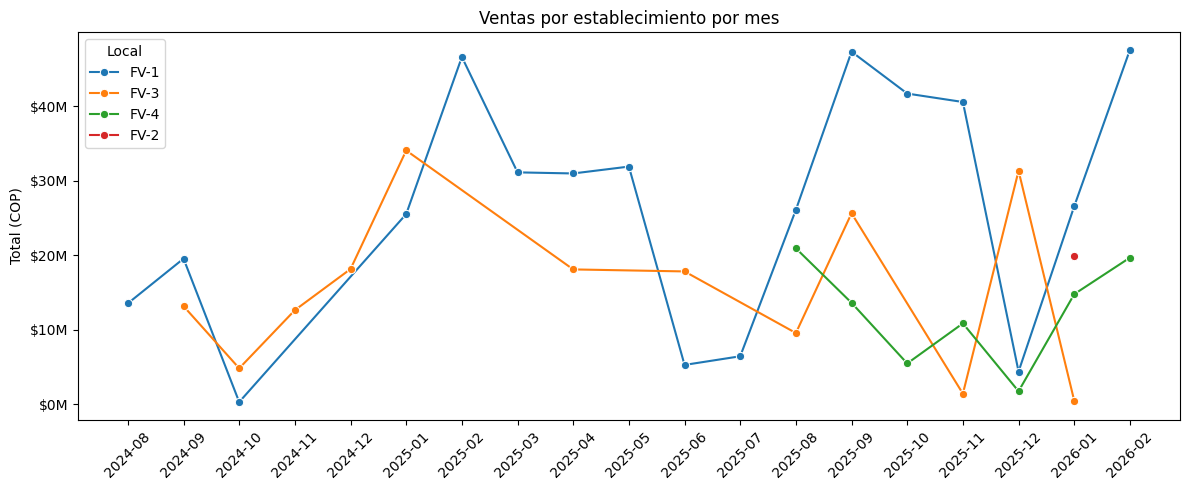

In [15]:

resumen = (
    ventas
    .groupby(["Periodo", "Número comprobante"])["Total"]
    .sum()
    .reset_index()
)

resumen["Periodo"] = resumen["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=resumen,
    x="Periodo",
    y="Total",
    hue="Número comprobante",
    marker="o"              # ← agrega puntos en cada mes
)
plt.xticks(rotation=45)
plt.title("Ventas por establecimiento por mes")
plt.ylabel("Total (COP)")
plt.xlabel("")
plt.legend(title="Local")  # ← título más claro en la leyenda

# Formato en millones en el eje Y
import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()


In [16]:
import pandas as pd
import plotly.express as px

# 1. Resumen de ventas
resumen_mes = (
    ventas
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)

# Convertir a string es vital para que no lo trate como fecha continua
resumen_mes["Periodo"] = resumen_mes["Periodo"].astype(str)

# 2. Gráfico interactivo
fig = px.bar(
    resumen_mes, 
    x="Periodo", 
    y="Total",
    title="Análisis de Ventas por Periodo",
    labels={"Total": "Monto ($)", "Periodo": "Mes"},
    text_auto='.2s', 
    color_discrete_sequence=["steelblue"]
)

# 3. Personalización estética (Aquí forzamos que aparezcan todos los meses con datos)
fig.update_layout(
    xaxis_tickangle=-45,
    # ESTA LÍNEA ES LA QUE ELIMINA LOS HUECOS VACÍOS COMO DICIEMBRE:
    xaxis_type='category', 
    yaxis_tickformat="$.2s", # Cambiado a .2s para que el eje diga $80M en lugar de $80,000,000
    hovermode="x unified",
    template="plotly_white"
)

# 4. Mostrar el gráfico
fig.show()


In [17]:
import plotly.express as px

# 1. Preparación (Asegúrate de convertir el periodo a texto para evitar los huecos)
resumen_compras_mes = (
    compras
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)
resumen_compras_mes["Periodo"] = resumen_compras_mes["Periodo"].astype(str)

# 2. Gráfico
fig = px.bar(
    resumen_compras_mes, 
    x="Periodo", 
    y="Total",
    title="Total Compras por Periodo",
    color_discrete_sequence=["#CD5C5C"] # Rojo similar al de tu imagen
)

# 3. El truco para quitar los huecos y poner el formato $18M
fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45,
    # ESTA LÍNEA QUITA LOS HUECOS:
    xaxis_type='category', 
    # ESTA LÍNEA PONE EL FORMATO $18M:
    yaxis_tickformat="$.2s", 
    hovermode="x unified"
)

# Personalizar el texto al pasar el mouse
fig.update_traces(
    hovertemplate="<b>Periodo:</b> %{x}<br><b>Total:</b> $%{y:,.0f}"
)

fig.show()


In [18]:
ventas_compras = resumen_mes.merge(
    resumen_compras_mes, 
    on="Periodo", 
    how="outer",
    suffixes=("_ventas", "_compras")
)

ventas_compras = ventas_compras.fillna(0)
ventas_compras["Utilidad"] = ventas_compras["Total_ventas"] - ventas_compras["Total_compras"]
ventas_compras = ventas_compras.sort_values("Periodo").reset_index(drop=True)

print(ventas_compras[["Periodo", "Total_ventas", "Total_compras", "Utilidad"]])


    Periodo  Total_ventas  Total_compras     Utilidad
0   2024-08   13552500.00     17591988.0  -4039488.00
1   2024-09   32727310.00            0.0  32727310.00
2   2024-10    5174300.00            0.0   5174300.00
3   2024-11   12644600.00            0.0  12644600.00
4   2024-12   18159161.00            0.0  18159161.00
5   2025-01   59576997.17      4249653.0  55327344.17
6   2025-02   46580484.50      3089645.0  43490839.50
7   2025-03   31114572.00      3692100.0  27422472.00
8   2025-04   49071040.40      4949213.0  44121827.40
9   2025-05   31888620.00      5764664.0  26123956.00
10  2025-06   23134199.26      2863814.0  20270385.26
11  2025-07    6460500.00      6150784.0    309716.00
12  2025-08   56603715.00      5242819.0  51360896.00
13  2025-09   86547085.00      9624248.0  76922837.00
14  2025-10   47174155.00      4496786.0  42677369.00
15  2025-11   52863172.00      5109383.0  47753789.00
16  2025-12   37505122.90      2227879.0  35277243.90
17  2026-01   61709036.00   

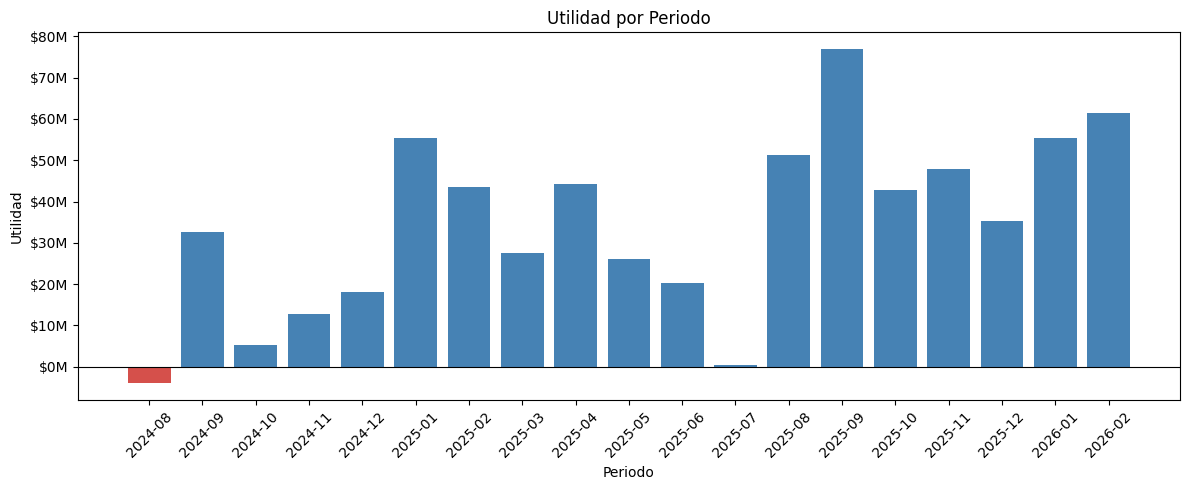

In [19]:
plt.figure(figsize=(12, 5))
plt.bar(ventas_compras["Periodo"], ventas_compras["Utilidad"], 
        color=["#d5504b" if x < 0 else "steelblue" for x in ventas_compras["Utilidad"]])
plt.title("Utilidad por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Utilidad")
plt.xticks(rotation=45)
plt.axhline(y=0, color="black", linewidth=0.8)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()


# Analisis productos



In [20]:
ventas_p=ventas[(ventas["Establecimiento"]=="Principal")&(ventas["Fecha"]>="2025-01-01")].sort_values("Fecha",ascending=True).reset_index()
dataset_p=ventas_p[["Fecha","Nombre","Cantidad","Total"]]


In [21]:
info_productos = dataset_p.groupby("Nombre").apply(lambda x: pd.Series({
    "transacciones": x["Nombre"].count(),
    "cantidad_total": x["Cantidad"].sum(),
    "precio_promedio": x["Total"].sum() / x["Cantidad"].sum(),
    "Plata generada":x["Total"].sum()
    
})).sort_values("transacciones", ascending=False)


In [22]:
# Definimos los puntos de corte
corte_x = info_productos["cantidad_total"].median()
corte_y = info_productos["Plata generada"].median()

# Función para asignar el color/categoría
def clasificar(row):
    if row["cantidad_total"] >= corte_x and row["Plata generada"] >= corte_y:
        return "ESTRELLA (Alto Vol / Alto $)"
    elif row["cantidad_total"] < corte_x and row["Plata generada"] >= corte_y:
        return "PREMIUM (Bajo Vol / Alto $)"
    elif row["cantidad_total"] >= corte_x and row["Plata generada"] < corte_y:
        return "GANCHO (Alto Vol / Bajo $)"
    else:
        return "BAJO DESEMPEÑO"

# Aplicamos la lógica al DataFrame
info_productos["Categoria_Matriz"] = info_productos.apply(clasificar, axis=1)

# ── Conteo por cuadrante ──────────────────────────────────────────────────────
conteos = info_productos["Categoria_Matriz"].value_counts()
n_estrella = conteos.get("ESTRELLA (Alto Vol / Alto $)", 0)
n_premium  = conteos.get("PREMIUM (Bajo Vol / Alto $)", 0)
n_gancho   = conteos.get("GANCHO (Alto Vol / Bajo $)", 0)
n_bajo     = conteos.get("BAJO DESEMPEÑO", 0)

import plotly.express as px

fig = px.scatter(
    info_productos.reset_index(), 
    x="cantidad_total", 
    y="Plata generada",
    color="Categoria_Matriz",
    color_discrete_map={
        "ESTRELLA (Alto Vol / Alto $)": "#2ecc71",
        "PREMIUM (Bajo Vol / Alto $)": "#3498db",
        "GANCHO (Alto Vol / Bajo $)": "#f1c40f",
        "BAJO DESEMPEÑO": "#e74c3c"
    },
    hover_name="Nombre",
    log_x=True, 
    log_y=True,
    hover_data=["precio_promedio", "transacciones"],
    title="Dashboard de Estrategia de Productos",
    template="plotly_white"
)

fig.update_traces(marker=dict(size=14, opacity=0.8, line=dict(width=1, color='white')))
fig.add_vline(x=corte_x, line_dash="dot", line_color="gray", opacity=0.5)
fig.add_hline(y=corte_y, line_dash="dot", line_color="gray", opacity=0.5)

# ── Anotaciones en las 4 esquinas ─────────────────────────────────────────────
anotaciones = [
    dict(x=0.99, y=0.99, text=f"<b> {n_estrella} productos</b>",
         font=dict(color="#27ae60", size=12),
         xanchor="right", yanchor="top"),
    dict(x=0.01, y=0.99, text=f"<b> {n_premium} productos</b>",
         font=dict(color="#2980b9", size=12),
         xanchor="left", yanchor="top"),
    dict(x=0.99, y=0.01, text=f"<b> {n_gancho} productos</b>",
         font=dict(color="#d4ac0d", size=12),
         xanchor="right", yanchor="bottom"),
    dict(x=0.01, y=0.01, text=f"<b> {n_bajo} productos</b>",
         font=dict(color="#c0392b", size=12),
         xanchor="left", yanchor="bottom"),
]

for a in anotaciones:
    fig.add_annotation(
        x=a["x"], y=a["y"],
        text=a["text"],
        showarrow=False,
        font=a["font"],
        xref="paper", yref="paper",
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="lightgray",
        borderwidth=1,
        borderpad=6,
        xanchor=a["xanchor"],
        yanchor=a["yanchor"],
    )

fig.update_layout(
    legend_title_text='Categoría de Negocio',
    font=dict(family="Verdana", size=12)
)

fig.show()


In [23]:
info_productos=info_productos.reset_index()


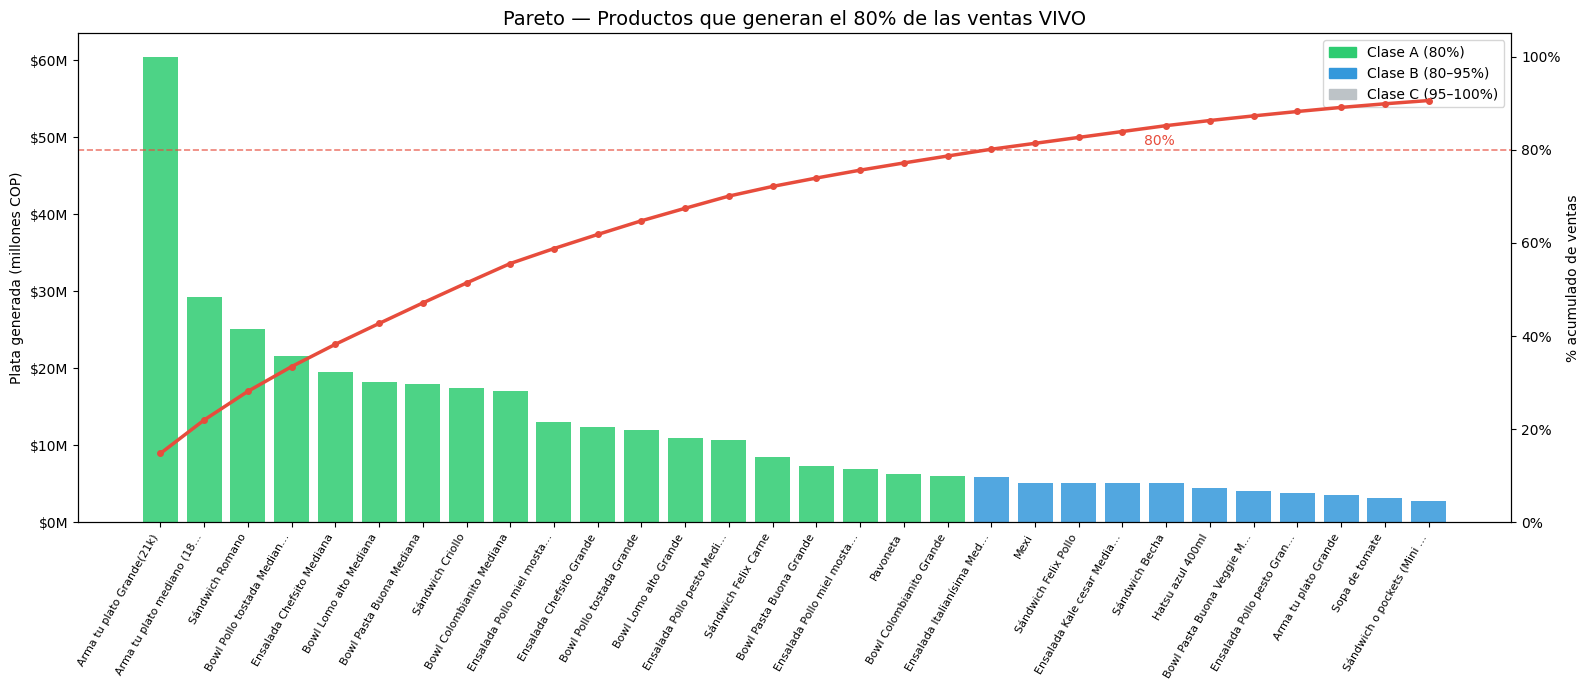


Resumen ABC:
Clase_ABC
C    37
B    21
A    19
Name: count, dtype: int64

Productos Clase A: 19
Plata generada Clase A: $320,704,951


In [24]:
# ── PASO 1: ordenar PRIMERO ───────────────────────────────────────
info_productos=info_productos[info_productos["Categoria_Matriz"]=="ESTRELLA (Alto Vol / Alto $)"]
info_productos = info_productos.sort_values('Plata generada', ascending=False).reset_index(drop=True)



# ── PASO 2: calcular pct DESPUÉS de ordenar ───────────────────────

total = info_productos['Plata generada'].sum()

info_productos['pct']      = info_productos['Plata generada'] / total

info_productos['pct_acum'] = info_productos['pct'].cumsum()



# ── PASO 3: clasificar ABC ────────────────────────────────────────

condiciones = [

    info_productos['pct_acum'] <= 0.80,

    info_productos['pct_acum'] <= 0.95,

]

info_productos['Clase_ABC'] = np.select(condiciones, ['A', 'B'], default='C')



# ── PASO 4: graficar ──────────────────────────────────────────────

n_mostrar = min(30, len(info_productos))

df_plot   = info_productos.head(n_mostrar)



colores = df_plot['Clase_ABC'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})



fig, ax1 = plt.subplots(figsize=(16, 7))



# Barras — plata generada

ax1.bar(range(n_mostrar), df_plot['Plata generada'] / 1_000_000, color=colores, alpha=0.85)

ax1.set_ylabel('Plata generada (millones COP)')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))



# Línea acumulada (eje derecho)

ax2 = ax1.twinx()

ax2.plot(range(n_mostrar), df_plot['pct_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)

ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)

ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)

ax2.set_ylabel('% acumulado de ventas')

ax2.set_ylim(0, 105)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))



# Etiquetas eje X

nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]

ax1.set_xticks(range(n_mostrar))

ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)



# Leyenda

leyenda = [

    Patch(color='#2ecc71', label='Clase A (80%)'),

    Patch(color='#3498db', label='Clase B (80–95%)'),

    Patch(color='#bdc3c7', label='Clase C (95–100%)'),

]

ax1.legend(handles=leyenda, loc='upper right')



plt.title('Pareto — Productos que generan el 80% de las ventas VIVO', fontsize=14)

plt.tight_layout()

plt.show()



print(f"\nResumen ABC:")

print(info_productos['Clase_ABC'].value_counts())

print(f"\nProductos Clase A: {(info_productos['Clase_ABC'] == 'A').sum()}")

print(f"Plata generada Clase A: ${info_productos[info_productos['Clase_ABC']=='A']['Plata generada'].sum():,.0f}")


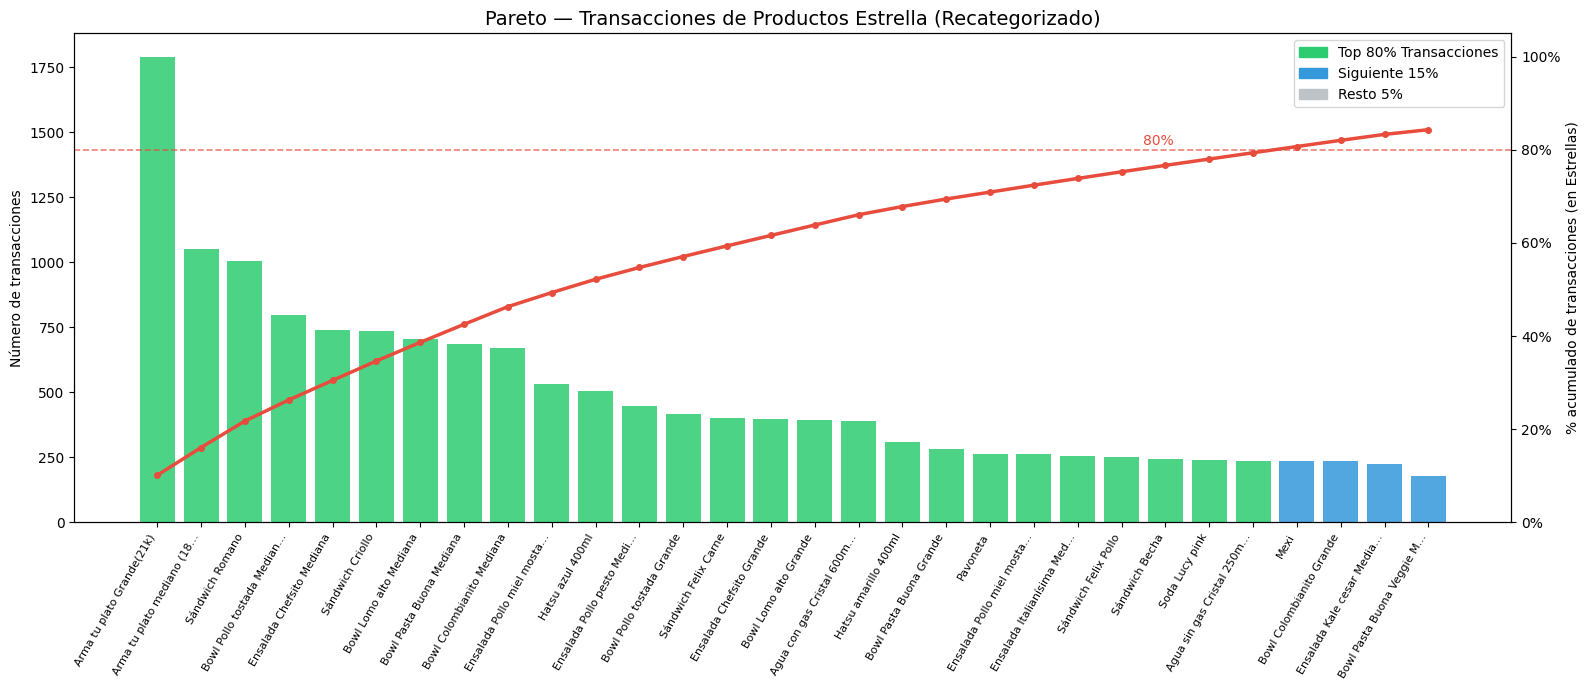

In [25]:
# 1. Filtrar solo los productos Estrella
df_estrella = info_productos[info_productos["Categoria_Matriz"] == "ESTRELLA (Alto Vol / Alto $)"].copy()

# 2. Ordenar por transacciones de mayor a menor
df_estrella = df_estrella.sort_values('transacciones', ascending=False).reset_index(drop=True)

# 3. Recalcular porcentajes sobre este nuevo total
total_trans_estrella = df_estrella['transacciones'].sum()
df_estrella['pct_trans']      = df_estrella['transacciones'] / total_trans_estrella
df_estrella['pct_trans_acum'] = df_estrella['pct_trans'].cumsum()

# 4. RECATEGORIZAR ABC (Solo para este grupo)
# Esto hará que los más vendidos de este grupo salgan en verde (A)
condiciones_estrella = [
    df_estrella['pct_trans_acum'] <= 0.80,
    df_estrella['pct_trans_acum'] <= 0.95,
]
df_estrella['Clase_ABC_Estrella'] = np.select(condiciones_estrella, ['A', 'B'], default='C')

# 5. Configurar visualización
n_mostrar = min(30, len(df_estrella))
df_plot = df_estrella.head(n_mostrar).copy()
colores = df_plot['Clase_ABC_Estrella'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})

# ── GRAFICAR ──────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 7))
ax1.bar(range(n_mostrar), df_plot['transacciones'], color=colores, alpha=0.85)
ax1.set_ylabel('Número de transacciones')

ax2 = ax1.twinx()
ax2.plot(range(n_mostrar), df_plot['pct_trans_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)
ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)

ax2.set_ylabel('% acumulado de transacciones (en Estrellas)')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]
ax1.set_xticks(range(n_mostrar))
ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)

leyenda = [
    Patch(color='#2ecc71', label='Top 80% Transacciones'), 
    Patch(color='#3498db', label='Siguiente 15%'), 
    Patch(color='#bdc3c7', label='Resto 5%')
]
ax1.legend(handles=leyenda, loc='upper right')

plt.title('Pareto — Transacciones de Productos Estrella (Recategorizado)', fontsize=14)
plt.tight_layout()
plt.show()


In [26]:
# 1. Extraer nombres de los Clase A de Ventas y de Transacciones (del segmento Estrella)
set_plata = set(info_productos[info_productos['Clase_ABC'] == 'A']['Nombre'])
set_trans = set(df_estrella[df_estrella['Clase_ABC_Estrella'] == 'A']['Nombre'])

# 2. Encontrar los que están en AMBOS (Intersección)
productos_criticos = list(set_plata.intersection(set_trans))

# 3. Crear el DataFrame final de productos críticos
df_criticos = info_productos[info_productos['Nombre'].isin(productos_criticos)].copy()

print(f"Se identificaron {len(productos_criticos)} productos críticos.")


Se identificaron 18 productos críticos.


In [27]:
# 1. Filtramos el DataFrame original para obtener solo los datos de los productos críticos
df_criticos = info_productos[info_productos['Nombre'].isin(productos_criticos)]

# 2. Ordenamos para que los más importantes salgan primero en la lista
df_criticos = df_criticos.sort_values('Plata generada', ascending=False)

print(f"Hay {len(productos_criticos)} productos que son Clase A en ambos criterios:\n")

for index, row in df_criticos.iterrows():
    nombre = row['Nombre']
    trans = row['transacciones']
    ventas = row['Plata generada']
    
    # Imprimimos con formato de miles y moneda para que sea profesional
    print(f" - {nombre[:30]:<30} | Transacciones: {int(trans):>4} | Ventas: ${ventas:,.0f}")


Hay 18 productos que son Clase A en ambos criterios:

 - Arma tu plato Grande(21k)      | Transacciones: 1790 | Ventas: $60,448,251
 - Arma tu plato mediano (18k)    | Transacciones: 1050 | Ventas: $29,244,050
 - Sándwich Romano                | Transacciones: 1004 | Ventas: $25,083,400
 - Bowl Pollo tostada Mediana     | Transacciones:  797 | Ventas: $21,658,500
 - Ensalada Chefsito Mediana      | Transacciones:  741 | Ventas: $19,507,000
 - Bowl Lomo alto Mediana         | Transacciones:  705 | Ventas: $18,218,000
 - Bowl Pasta Buona Mediana       | Transacciones:  684 | Ventas: $17,973,300
 - Sándwich Criollo               | Transacciones:  735 | Ventas: $17,476,050
 - Bowl Colombianito Mediana      | Transacciones:  669 | Ventas: $17,026,900
 - Ensalada Pollo miel mostaza Me | Transacciones:  532 | Ventas: $13,082,600
 - Ensalada Chefsito Grande       | Transacciones:  396 | Ventas: $12,352,600
 - Bowl Pollo tostada Grande      | Transacciones:  415 | Ventas: $11,961,400
 - Bowl Lo

# Preparar datos para el pronostico

In [ ]:
ventas_criticas=dataset_p[dataset_p["Nombre"].isin(productos_criticos)].reset_index()
ventas_criticas.drop(columns=["index"],inplace=True)
ventas_criticas.head(10)


,Fecha,Nombre,Cantidad,Total
0,2025-01-24,Sándwich Romano,1.0,18500.0
1,2025-01-24,Bowl Lomo alto Mediana,1.0,21000.0
2,2025-01-24,Bowl Pollo tostada Mediana,1.0,21000.0
3,2025-01-24,Bowl Pasta Buona Mediana,1.0,21000.0
4,2025-01-24,Sándwich Felix Carne,1.0,18500.0
5,2025-01-24,Sándwich Criollo,1.0,18500.0
6,2025-01-24,Bowl Pasta Buona Mediana,4.0,84000.0
7,2025-01-24,Arma tu plato Grande(21k),1.0,21000.0
8,2025-01-24,Sándwich Romano,1.0,18500.0
9,2025-01-24,Sándwich Criollo,1.0,16500.0


In [29]:
def preparar_serie(df, nombre_producto):
    df_prod = df[df['Nombre'] == nombre_producto].copy()
    
    # Agrupar por día
    serie = df_prod.groupby('Fecha')['Cantidad'].sum().reset_index()
    
    # Renombrar al formato Prophet
    serie = serie.rename(columns={'Fecha': 'ds', 'Cantidad': 'y'})
    
    # Rellenar días sin ventas con 0
    rango = pd.date_range(serie['ds'].min(), serie['ds'].max(), freq='D')
    serie = serie.set_index('ds').reindex(rango, fill_value=0).reset_index()
    serie = serie.rename(columns={'index': 'ds'})
    
    return serie



In [ ]:
# Prueba con el producto top
serie_test = preparar_serie(ventas_criticas, 'Arma tu plato Grande(21k)')

print(f"Días totales: {len(serie_test)}")
print(f"Días con ventas: {(serie_test['y'] > 0).sum()}")
print(f"Días sin ventas: {(serie_test['y'] == 0).sum()}")
print(f"Fecha inicio: {serie_test['ds'].min()}")
print(f"Fecha fin: {serie_test['ds'].max()}")
print(f"Máximo en un día: {serie_test['y'].max()}")
serie_test.head(10)


Días totales: 389
Días con ventas: 204
Días sin ventas: 185
Fecha inicio: 2025-01-24 00:00:00
Fecha fin: 2026-02-16 00:00:00
Máximo en un día: 55.0


,ds,y
0,2025-01-24,13.0
1,2025-01-25,0.0
2,2025-01-26,30.0
3,2025-01-27,11.0
4,2025-01-28,7.0
5,2025-01-29,14.0
6,2025-01-30,9.0
7,2025-01-31,10.0
8,2025-02-01,0.0
9,2025-02-02,0.0


In [ ]:
def entrenar_prophet(serie):
    
    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative'
    )
    
    modelo.add_country_holidays(country_name='CO')
    modelo.fit(serie)
    
    futuro = modelo.make_future_dataframe(periods=30)
    forecast = modelo.predict(futuro)
    
    # Redondear y eliminar negativos
    forecast['yhat']       = forecast['yhat'].clip(lower=0).round(0)
    forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0).round(0)
    forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0).round(0)
    
    return modelo, forecast


In [ ]:
# Paso 1: preparar la serie
serie_test = preparar_serie(ventas_criticas, 'Arma tu plato Grande(21k)')

# Paso 2: entrenar
modelo_test, forecast_test = entrenar_prophet(serie_test)

# Paso 3: ver los últimos 30 días pronosticados
forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)


17:34:33 - cmdstanpy - INFO - Chain [1] start processing
17:34:33 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
389,2026-02-17,16.0,7.0,24.0
390,2026-02-18,17.0,9.0,24.0
391,2026-02-19,15.0,7.0,23.0
392,2026-02-20,12.0,4.0,20.0
393,2026-02-21,1.0,0.0,8.0
394,2026-02-22,1.0,0.0,9.0
395,2026-02-23,12.0,4.0,19.0
396,2026-02-24,14.0,7.0,23.0
397,2026-02-25,15.0,7.0,23.0
398,2026-02-26,14.0,5.0,22.0


In [ ]:
print(metricas.columns.tolist())
print(metricas.tail(10))


['horizon', 'mse', 'rmse', 'mae', 'mdape', 'smape', 'coverage']
   horizon         mse       rmse        mae      mdape     smape  coverage
18 21 days  352.882216  18.785159  14.470322   6.670961  1.361812  0.388889
19 22 days  409.364464  20.232757  15.358077        inf  1.561190  0.388889
20 23 days  375.865007  19.387238  14.976969        inf  1.564059  0.333333
21 24 days  329.720793  18.158216  14.327350        inf  1.536333  0.333333
22 25 days  280.767427  16.756116  13.762007        inf  1.497724  0.277778
23 26 days  331.818110  18.215875  15.790060  17.207764  1.491926  0.166667
24 27 days  339.288036  18.419773  16.085729   2.932353  1.450057  0.111111
25 28 days  401.665317  20.041590  17.412797  12.441829  1.527922  0.111111
26 29 days  359.131472  18.950764  15.344867        inf  1.697301  0.277778
27 30 days  334.061091  18.277338  15.033122        inf  1.766314  0.277778


In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

# Cross validation
cv_results = cross_validation(
    modelo_test,
    initial='180 days',   # entrena con los primeros 6 meses
    period='30 days',     # cada 30 días corre una nueva ventana
    horizon='30 days'     # predice 30 días hacia adelante
)

# Métricas
metricas = performance_metrics(cv_results)
print(metricas[['horizon', 'mdape', 'smape', 'rmse', 'mae']].tail(10))


Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/6 [00:00<?, ?it/s]

17:37:35 - cmdstanpy - INFO - Chain [1] start processing
17:37:35 - cmdstanpy - INFO - Chain [1] done processing
17:37:35 - cmdstanpy - INFO - Chain [1] start processing
17:37:36 - cmdstanpy - INFO - Chain [1] done processing
17:37:36 - cmdstanpy - INFO - Chain [1] start processing
17:37:36 - cmdstanpy - INFO - Chain [1] done processing
17:37:36 - cmdstanpy - INFO - Chain [1] start processing
17:37:36 - cmdstanpy - INFO - Chain [1] done processing
17:37:36 - cmdstanpy - INFO - Chain [1] start processing
17:37:36 - cmdstanpy - INFO - Chain [1] done processing
17:37:37 - cmdstanpy - INFO - Chain [1] start processing
17:37:37 - cmdstanpy - INFO - Chain [1] done processing


   horizon      mdape     smape       rmse        mae
18 21 days   6.670961  1.361812  18.785159  14.470322
19 22 days        inf  1.561190  20.232757  15.358077
20 23 days        inf  1.564059  19.387238  14.976969
21 24 days        inf  1.536333  18.158216  14.327350
22 25 days        inf  1.497724  16.756116  13.762007
23 26 days  17.207764  1.491926  18.215875  15.790060
24 27 days   2.932353  1.450057  18.419773  16.085729
25 28 days  12.441829  1.527922  20.041590  17.412797
26 29 days        inf  1.697301  18.950764  15.344867
27 30 days        inf  1.766314  18.277338  15.033122


In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics
import warnings
warnings.filterwarnings('ignore')  # silencia los mensajes de cmdstanpy

resultados = {}

for producto in productos_criticos:
    print(f"Entrenando: {producto}...")
    
    serie = preparar_serie(ventas_criticas, producto)
    modelo, forecast = entrenar_prophet(serie)
    
    # Ajustar cross validation según tamaño de la serie
    n_dias = len(serie)
    initial = f'{int(n_dias * 0.6)} days'  # 60% para entrenar
    horizon = '30 days'
    period  = '15 days'
    
    try:
        cv = cross_validation(modelo, initial=initial, period=period, horizon=horizon)
        metricas = performance_metrics(cv)
        smape_30 = metricas['smape'].iloc[-1]
        mae_30   = metricas['mae'].iloc[-1]
    except Exception as e:
        print(f"  CV falló: {e}")
        smape_30 = None
        mae_30   = None
    
    resultados[producto] = {
        'modelo':    modelo,
        'forecast':  forecast,
        'smape':     round(smape_30, 3) if smape_30 else None,
        'mae':       round(mae_30, 1)   if mae_30   else None
    }
    
    print(f"  SMAPE: {smape_30:.3f} | MAE: {mae_30:.1f}" if smape_30 else "  Sin métricas")

print("\nListo!")


Entrenando: Bowl Colombianito Mediana...


17:39:55 - cmdstanpy - INFO - Chain [1] start processing
17:39:55 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/9 [00:00<?, ?it/s]

17:39:56 - cmdstanpy - INFO - Chain [1] start processing
17:39:56 - cmdstanpy - INFO - Chain [1] done processing
17:39:56 - cmdstanpy - INFO - Chain [1] start processing
17:39:56 - cmdstanpy - INFO - Chain [1] done processing
17:39:56 - cmdstanpy - INFO - Chain [1] start processing
17:39:56 - cmdstanpy - INFO - Chain [1] done processing
17:39:57 - cmdstanpy - INFO - Chain [1] start processing
17:39:57 - cmdstanpy - INFO - Chain [1] done processing
17:39:57 - cmdstanpy - INFO - Chain [1] start processing
17:39:57 - cmdstanpy - INFO - Chain [1] done processing
17:39:57 - cmdstanpy - INFO - Chain [1] start processing
17:39:57 - cmdstanpy - INFO - Chain [1] done processing
17:39:58 - cmdstanpy - INFO - Chain [1] start processing
17:39:58 - cmdstanpy - INFO - Chain [1] done processing
17:39:58 - cmdstanpy - INFO - Chain [1] start processing
17:39:58 - cmdstanpy - INFO - Chain [1] done processing
17:39:58 - cmdstanpy - INFO - Chain [1] start processing
17:39:59 - cmdstanpy - INFO - Chain [1]

  SMAPE: 1.376 | MAE: 2.5
Entrenando: Bowl Lomo alto Grande...


...

  SMAPE: 1.266 | MAE: 1.6
Entrenando: Ensalada Pollo miel mostaza Grande...


17:41:01 - cmdstanpy - INFO - Chain [1] start processing
17:41:01 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/9 [00:00<?, ?it/s]

17:41:02 - cmdstanpy - INFO - Chain [1] start processing
17:41:02 - cmdstanpy - INFO - Chain [1] done processing
17:41:02 - cmdstanpy - INFO - Chain [1] start processing
17:41:02 - cmdstanpy - INFO - Chain [1] done processing
17:41:03 - cmdstanpy - INFO - Chain [1] start processing
17:41:03 - cmdstanpy - INFO - Chain [1] done processing
17:41:03 - cmdstanpy - INFO - Chain [1] start processing
17:41:03 - cmdstanpy - INFO - Chain [1] done processing
17:41:03 - cmdstanpy - INFO - Chain [1] start processing
17:41:03 - cmdstanpy - INFO - Chain [1] done processing
17:41:04 - cmdstanpy - INFO - Chain [1] start processing
17:41:04 - cmdstanpy - INFO - Chain [1] done processing
17:41:04 - cmdstanpy - INFO - Chain [1] start processing
17:41:04 - cmdstanpy - INFO - Chain [1] done processing
17:41:04 - cmdstanpy - INFO - Chain [1] start processing
17:41:05 - cmdstanpy - INFO - Chain [1] done processing
17:41:05 - cmdstanpy - INFO - Chain [1] start processing
17:41:05 - cmdstanpy - INFO - Chain [1]

  SMAPE: 1.666 | MAE: 0.9

Listo!


In [ ]:
# Convertir resultados a tabla
resumen_prophet = pd.DataFrame([
    {
        'Producto': producto,
        'SMAPE': datos['smape'],
        'MAE': datos['mae'],
        'Dias_historia': len(preparar_serie(ventas_criticas, producto))
    }
    for producto, datos in resultados.items()
])

# Ordenar por SMAPE
resumen = resumen_prophet.sort_values('SMAPE')
print(resumen_prophet.to_string(index=False))


                           Producto  SMAPE  MAE  Dias_historia
          Bowl Colombianito Mediana  1.376  2.5            400
              Bowl Lomo alto Grande  1.370  2.0            400
Ensalada Pollo miel mostaza Mediana  1.489  2.5            400
           Ensalada Chefsito Grande  1.388  1.4            400
         Bowl Pollo tostada Mediana  1.279  3.3            400
             Bowl Lomo alto Mediana  1.177  2.7            399
          Bowl Pollo tostada Grande  1.269  1.8            400
                           Pavoneta  1.379  3.0            192
                   Sándwich Criollo  1.178  4.1            400
        Arma tu plato mediano (18k)  1.654  3.9            389
           Bowl Pasta Buona Mediana  1.280  3.0            400
               Sándwich Felix Carne  1.570  1.4            399
          Ensalada Chefsito Mediana  1.543  3.4            400
                    Sándwich Romano  1.185  4.5            400
          Arma tu plato Grande(21k)  1.758 13.2        